# EfficientNetV2-S — Task-Specific Adapters
Bottleneck CNN adapters inserted after selected feature stages; backbone frozen.

In [1]:
import os

os.chdir("..")  
print(os.getcwd())

/Users/peter/Documents/MDS_UBC/DATA_586/food_classification


In [2]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.models import EfficientNet_V2_S_Weights

from helpers import (
    get_food101_loaders, run_training, plot_results, count_trainable_params
)

In [3]:
class CNNAdapter(nn.Module):
    """Lightweight bottleneck residual adapter."""
    def __init__(self, channels: int, reduction_factor: int = 8):
        super().__init__()
        bottleneck = channels // reduction_factor
        self.adapter = nn.Sequential(
            nn.Conv2d(channels, bottleneck, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(bottleneck, channels, kernel_size=1),
        )

    def forward(self, x):
        return x + self.adapter(x)


class EfficientNetWithAdapters(nn.Module):
    def __init__(self, backbone, adapter_indices=(3, 5, 6)):
        super().__init__()
        self.model           = backbone
        self.adapter_indices = list(adapter_indices)
        self.adapters        = nn.ModuleDict({
            str(i): CNNAdapter(self._out_channels(i))
            for i in self.adapter_indices
        })

    def _out_channels(self, idx: int) -> int:
        return self.model.features[idx][-1].out_channels

    def forward(self, x):
        for i, layer in enumerate(self.model.features):
            x = layer(x)
            if str(i) in self.adapters:
                x = self.adapters[str(i)](x)
        x = self.model.avgpool(x)
        x = torch.flatten(x, 1)
        return self.model.classifier(x)

In [4]:
weights   = EfficientNet_V2_S_Weights.DEFAULT
transform = weights.transforms()

train_loader, val_loader = get_food101_loaders(transform, batch_size=256, num_workers=8)

backbone = models.efficientnet_v2_s(weights=weights)
model    = EfficientNetWithAdapters(backbone, adapter_indices=(3, 5, 6))

# Freeze backbone
for param in model.model.parameters():
    param.requires_grad = False

# Replace & unfreeze classifier
model.model.classifier[1] = nn.Linear(model.model.classifier[1].in_features, 101)
for param in model.model.classifier.parameters():
    param.requires_grad = True

# Unfreeze adapters
for param in model.adapters.parameters():
    param.requires_grad = True

print(f"Trainable params: {count_trainable_params(model):,}")

Trainable params: 153,729


In [5]:
model, train_losses, val_losses, train_accs, val_accs = run_training(
    model=model,
    model_name="efficientnet_task_specific_adapters",
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    epochs=8,
    lr=1e-3,
)

[efficientnet_task_specific_adapters] Final checkpoint found — loading metrics for plotting.


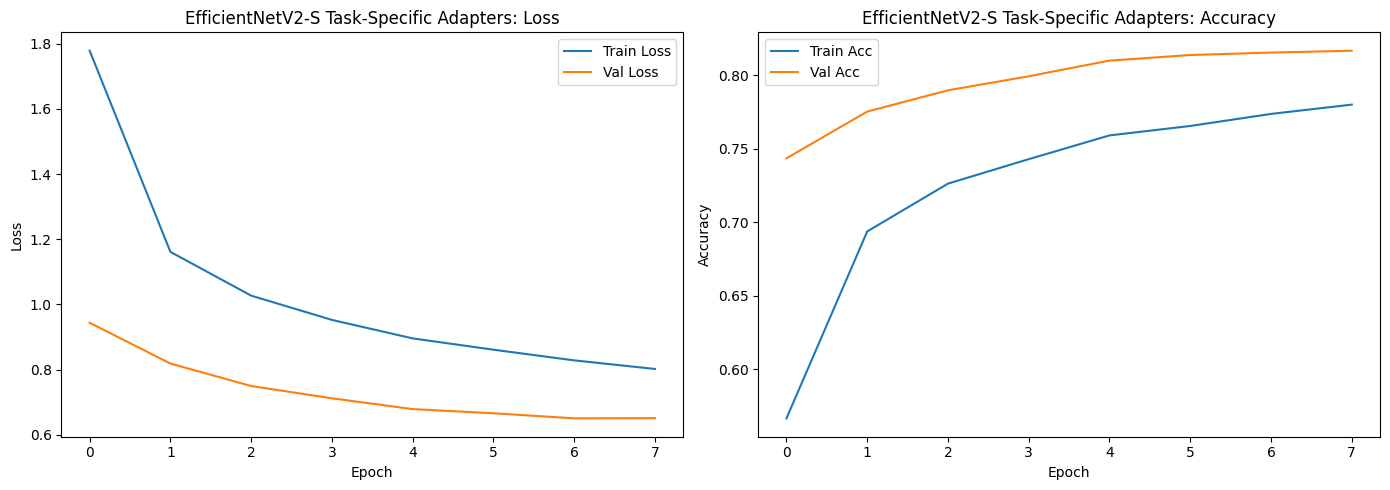

In [6]:
plot_results(train_losses, val_losses, train_accs, val_accs, "EfficientNetV2-S Task-Specific Adapters")